In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
city_files = [
    'Atlanta_climate_v2.csv', 
    'Chicago_climate_v2.csv', 
    'Los_Angeles_climate_v2.csv', 
    'New_York_climate_v2.csv', 
    'San_Francisco_climate_v2.csv', 
    'St_Louis_climate_v2.csv'
]

print(f"check")

check


In [17]:
all_data = []

for file in city_files:
    if os.path.exists(file):
        temp_df = pd.read_csv(file)
        temp_df['time'] = pd.to_datetime(temp_df['time'])
        city_name = file.split('_')[0]
        temp_df['City'] = city_name
        temp_df['is_rainy'] = (temp_df['pr'] > 0.0001).astype(int)
        all_data.append(temp_df)
df_master = pd.concat(all_data, ignore_index=True)
print(f"check")

check


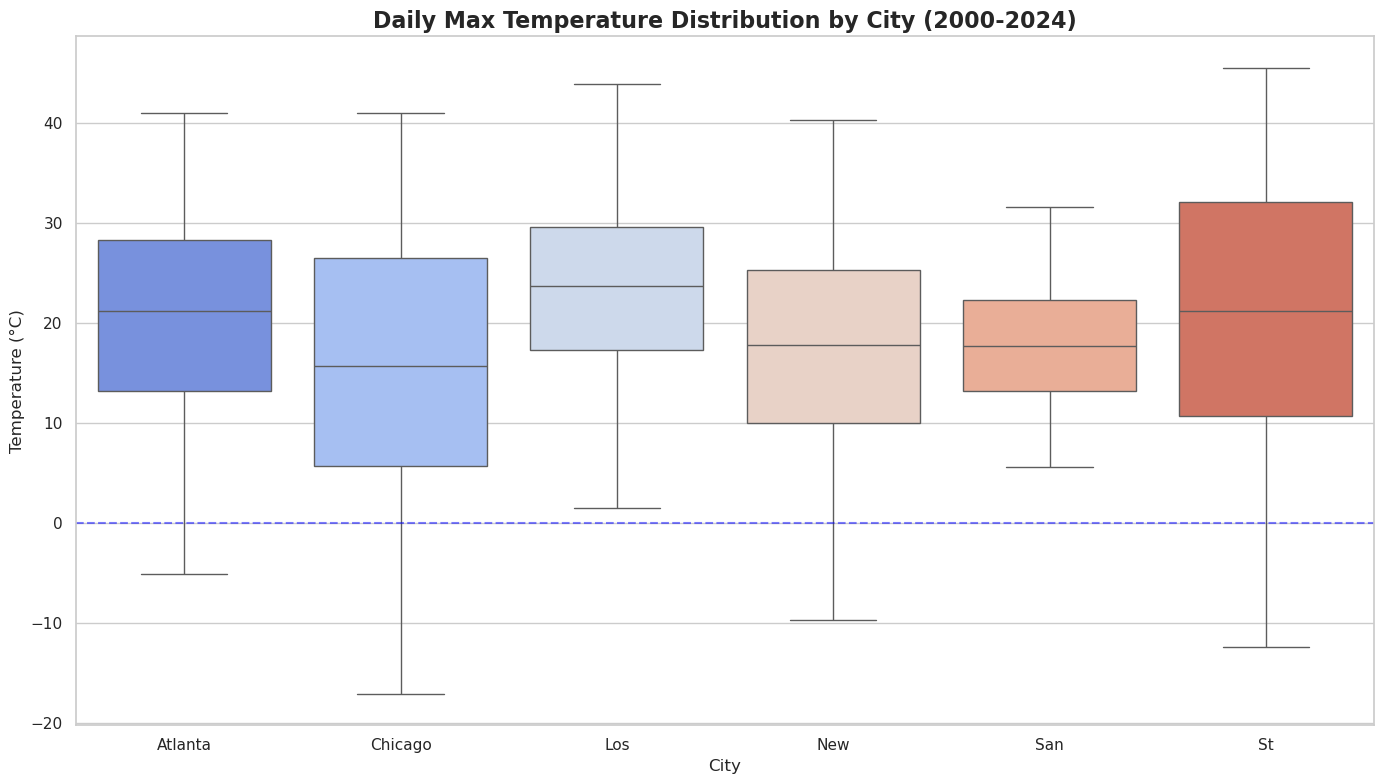

In [11]:
plt.figure(figsize=(14, 8))
sns.set_theme(style="whitegrid")
sns.boxplot(data=df_master, x='City', y='tasmax', palette='coolwarm', hue='City', legend=False)
plt.title('Daily Max Temperature Distribution by City (2000-2024)', fontsize=16, weight='bold')
plt.ylabel('Temperature (°C)', fontsize=12)
plt.xlabel('City', fontsize=12)
plt.axhline(0, color='blue', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

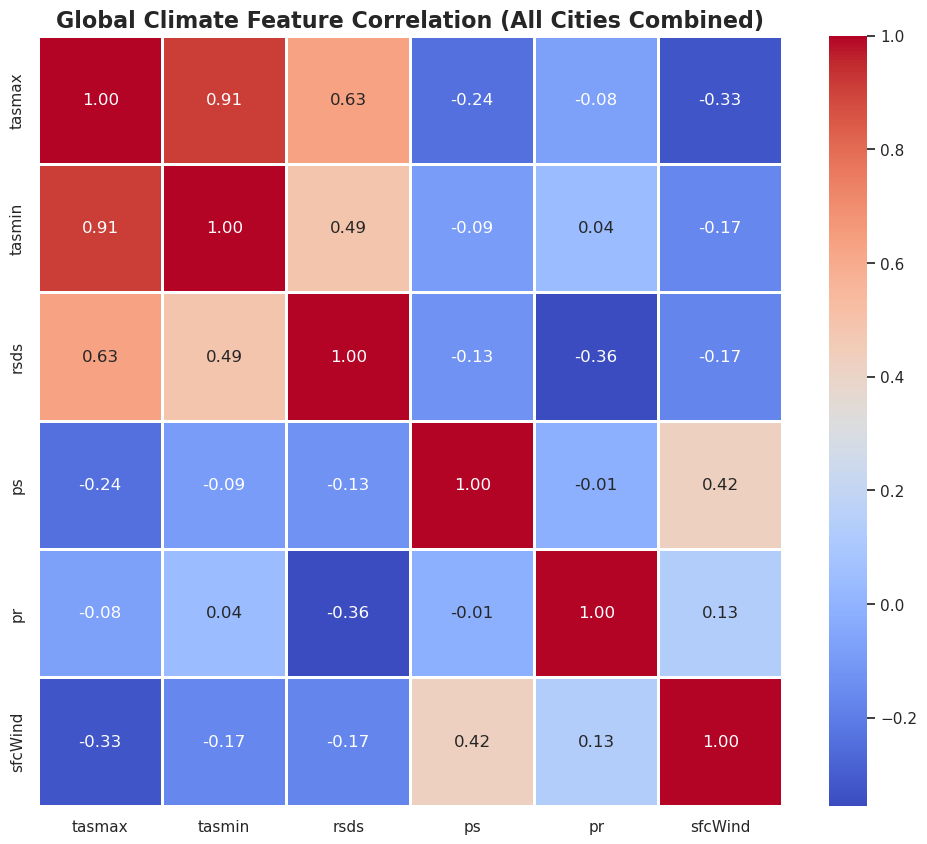

In [12]:
plt.figure(figsize=(12, 10))
features = ['tasmax', 'tasmin', 'rsds', 'ps', 'pr', 'sfcWind']
global_corr = df_master[features].corr()
sns.heatmap(global_corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=1)
plt.title('Global Climate Feature Correlation (All Cities Combined)', fontsize=16, weight='bold')
plt.show()

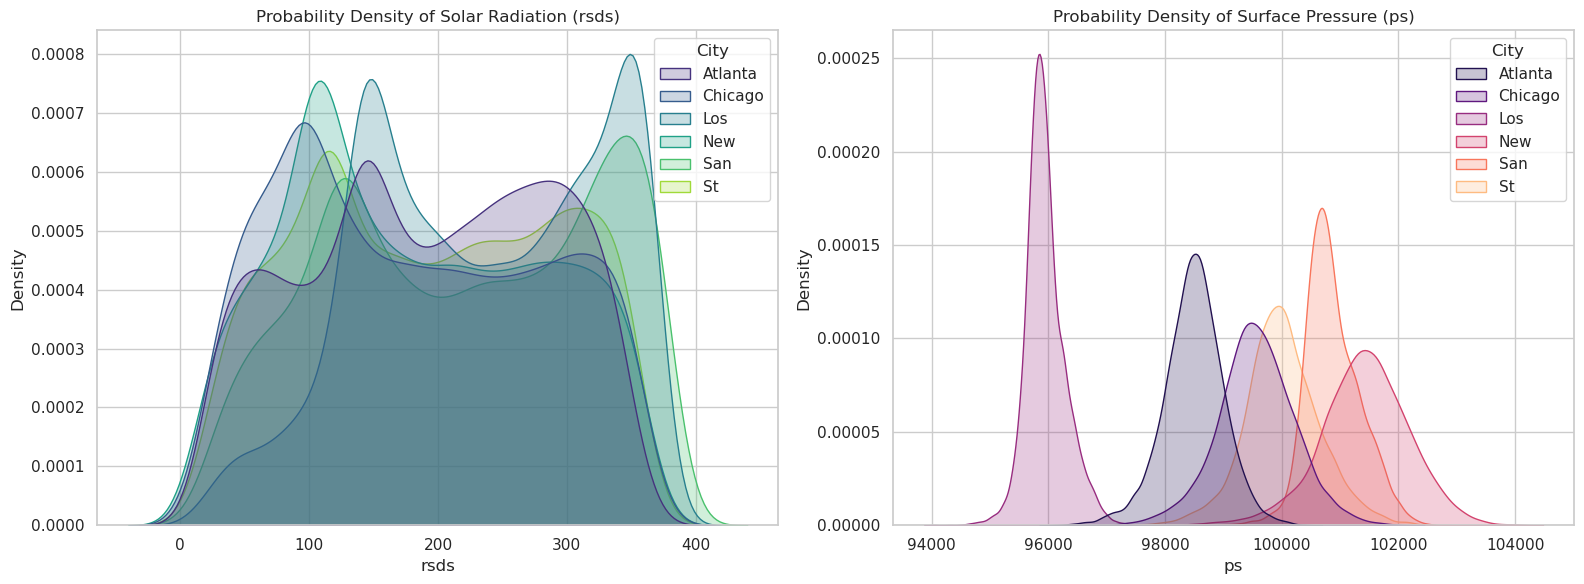

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
sns.kdeplot(data=df_master, x='rsds', hue='City', fill=True, ax=ax1, palette='viridis')
ax1.set_title('Probability Density of Solar Radiation (rsds)')
sns.kdeplot(data=df_master, x='ps', hue='City', fill=True, ax=ax2, palette='magma')
ax2.set_title('Probability Density of Surface Pressure (ps)')
plt.tight_layout()
plt.show()

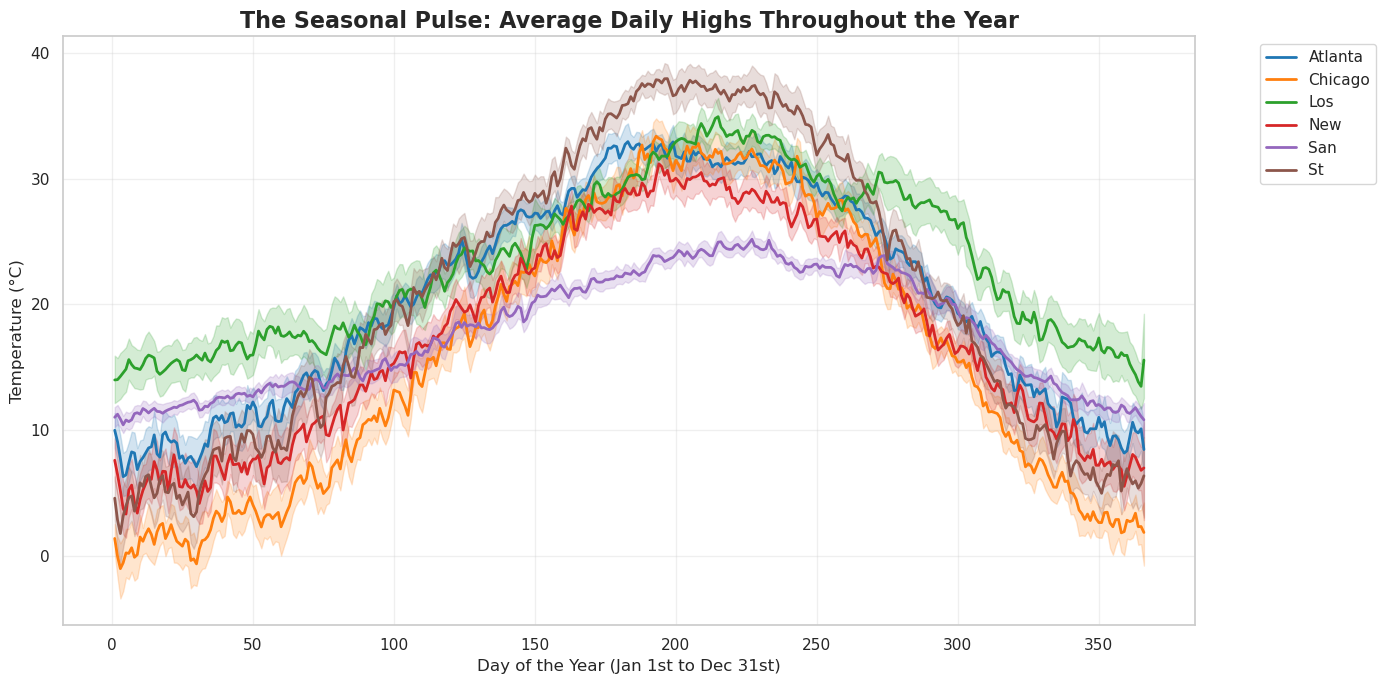

In [21]:
df_master['day_of_year'] = df_master['time'].dt.dayofyear

plt.figure(figsize=(14, 7))

sns.lineplot(data=df_master, x='day_of_year', y='tasmax', hue='City', palette='tab10', linewidth=2)

plt.title('Average Daily Highs Throughout the Year', fontsize=16, weight='bold')
plt.xlabel('Day of the Year (Jan 1st to Dec 31st)', fontsize=12)
plt.ylabel('Temperature (°C)', fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()